# Association Rule Mining

In [3]:
import pandas as pd

In [4]:
# Association Rule Mining
# Using the full cleaned dataset and extracting just the survey response ID (representing the customer) and the titles of products purchased by each customer

# Using a copy of the dataset before encoding, so we can see item names when doing ARM instead of numeric labels
data_unencoded = pd.read_csv('/workspaces/group-project-bas-team/data/data_unencoded.csv')


# Attempting ARM with categories first
purchases_by_customer = data_unencoded.groupby('Survey ResponseID')['Category'].apply(list).tolist()

In [5]:
%pip install mlxtend

/usr/local/python/3.12.1/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=14788) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
from mlxtend.preprocessing import TransactionEncoder

encoder = TransactionEncoder()
encoding = encoder.fit_transform(purchases_by_customer)
transaction_data = pd.DataFrame(encoding, columns=encoder.columns_)

In [11]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(transaction_data, min_support=0.3, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.831510,frozenset({ABIS_BOOK})
1,0.376368,frozenset({ADHESIVE_TAPES})
2,0.323851,frozenset({BACKPACK})
3,0.531729,frozenset({BATTERY})
4,0.514223,frozenset({BEAUTY})
...,...,...
2153,0.304158,"frozenset({NUTRITIONAL_SUPPLEMENT, HEALTH_PERS..."
2154,0.308534,"frozenset({HEALTH_PERSONAL_CARE, SHIRT, HEADPH..."
2155,0.323851,"frozenset({HEALTH_PERSONAL_CARE, ELECTRONIC_CA..."
2156,0.301969,"frozenset({HEALTH_PERSONAL_CARE, ELECTRONIC_CA..."


We will start our analysis of association rules by examining confidence, which tells us how often each consequent is purchased by the same customer that purchased the antecedent

In [65]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5, num_itemsets=len(transaction_data.index))
rules = rules.sort_values('confidence', ascending=False)
rules = rules.head(50)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1422,"frozenset({DRINKING_CUP, HOME})",frozenset({ABIS_BOOK}),0.341357,0.83151,0.339168,0.993590,1.194922,1.0,0.055327,26.284464,0.247669,0.406824,0.961955,0.700742
1427,"frozenset({MEDICATION, DRINKING_CUP})",frozenset({ABIS_BOOK}),0.326039,0.83151,0.323851,0.993289,1.194560,1.0,0.052746,25.105033,0.241664,0.388451,0.960167,0.691381
6194,"frozenset({CELLULAR_PHONE_CASE, SKIN_MOISTURIZ...",frozenset({ABIS_BOOK}),0.321663,0.83151,0.319475,0.993197,1.194450,1.0,0.052009,24.768053,0.239991,0.383202,0.959625,0.688704
1477,"frozenset({WRITING_INSTRUMENT, DRINKING_CUP})",frozenset({ABIS_BOOK}),0.317287,0.83151,0.315098,0.993103,1.194338,1.0,0.051271,24.431072,0.238337,0.377953,0.959069,0.686025
6206,"frozenset({CELLULAR_PHONE_CASE, SOCKS, DRINKIN...",frozenset({ABIS_BOOK}),0.308534,0.83151,0.306346,0.992908,1.194102,1.0,0.049797,23.757112,0.235081,0.367454,0.957907,0.680664
1465,"frozenset({SOCKS, DRINKING_CUP})",frozenset({ABIS_BOOK}),0.345733,0.83151,0.341357,0.987342,1.187408,1.0,0.053876,13.310722,0.241231,0.408377,0.924873,0.698934
6789,"frozenset({CELLULAR_PHONE_CASE, WRITING_INSTRU...",frozenset({ABIS_BOOK}),0.332604,0.83151,0.328228,0.986842,1.186807,1.0,0.051664,12.805252,0.235847,0.392670,0.921907,0.690789
5889,"frozenset({ELECTRONIC_CABLE, CELLULAR_PHONE_CA...",frozenset({ABIS_BOOK}),0.330416,0.83151,0.326039,0.986755,1.186703,1.0,0.051295,12.721007,0.234965,0.390052,0.921390,0.689430
6410,"frozenset({ELECTRONIC_CABLE, CELLULAR_PHONE_CA...",frozenset({ABIS_BOOK}),0.323851,0.83151,0.319475,0.986486,1.186380,1.0,0.050189,12.468271,0.232345,0.382199,0.919796,0.685349
7753,"frozenset({SOCKS, DRINKING_CUP, SHIRT})",frozenset({ABIS_BOOK}),0.317287,0.83151,0.312910,0.986207,1.186044,1.0,0.049083,12.215536,0.229761,0.374346,0.918137,0.681261


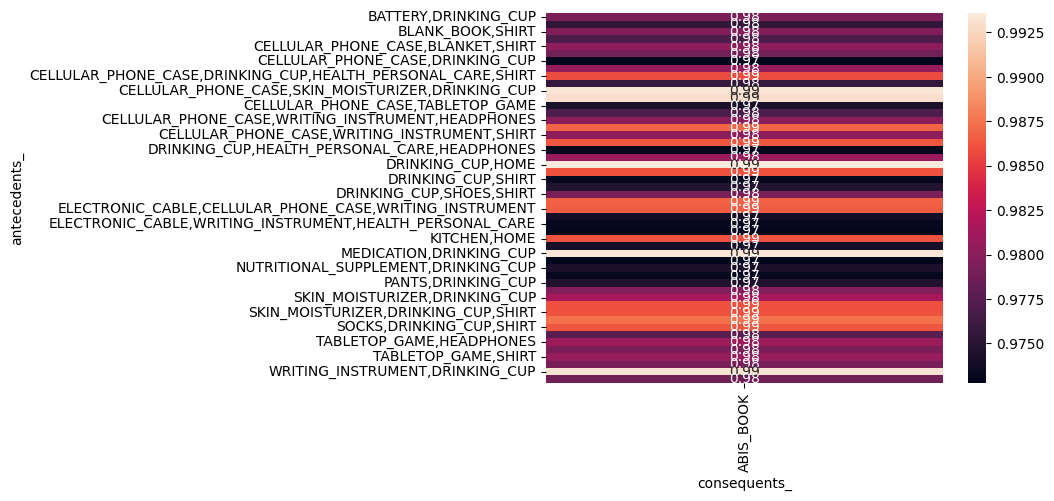

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

rules['lhs items'] = rules['antecedents'].apply(lambda x:len(x) )

# Replace frozen sets with strings
rules['antecedents_'] = rules['antecedents'].apply(lambda a: ','.join(list(a)))
rules['consequents_'] = rules['consequents'].apply(lambda a: ','.join(list(a)))

pivot = rules.pivot(index = 'antecedents_', columns = 'consequents_', values= 'confidence')

# Generate a heatmap with annotations on and the colorbar off
sns.heatmap(pivot, annot = True)
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.show()

Examining support, which tells us how often items are purchased by the same customer

In [53]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="support", min_threshold=0.5, num_itemsets=len(transaction_data.index))
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({CELLULAR_PHONE_CASE}),frozenset({ABIS_BOOK}),0.687090,0.831510,0.617068,0.898089,1.080070,1.0,0.045746,1.653310,0.236919,0.684466,0.395153,0.820097
1,frozenset({ABIS_BOOK}),frozenset({CELLULAR_PHONE_CASE}),0.831510,0.687090,0.617068,0.742105,1.080070,1.0,0.045746,1.213326,0.439993,0.684466,0.175819,0.820097
2,frozenset({CHARGING_ADAPTER}),frozenset({ABIS_BOOK}),0.590810,0.831510,0.512035,0.866667,1.042281,1.0,0.020771,1.263676,0.099136,0.562500,0.208658,0.741228
3,frozenset({ABIS_BOOK}),frozenset({CHARGING_ADAPTER}),0.831510,0.590810,0.512035,0.615789,1.042281,1.0,0.020771,1.065016,0.240759,0.562500,0.061047,0.741228
4,frozenset({ELECTRONIC_CABLE}),frozenset({ABIS_BOOK}),0.704595,0.831510,0.614880,0.872671,1.049501,1.0,0.029002,1.323264,0.159668,0.667458,0.244293,0.806072
5,frozenset({ABIS_BOOK}),frozenset({ELECTRONIC_CABLE}),0.831510,0.704595,0.614880,0.739474,1.049501,1.0,0.029002,1.133877,0.279937,0.667458,0.118070,0.806072
6,frozenset({ABIS_BOOK}),frozenset({HEADPHONES}),0.831510,0.698031,0.603939,0.726316,1.040521,1.0,0.023519,1.103350,0.231131,0.652482,0.093669,0.795760
7,frozenset({HEADPHONES}),frozenset({ABIS_BOOK}),0.698031,0.831510,0.603939,0.865204,1.040521,1.0,0.023519,1.249962,0.128965,0.652482,0.199976,0.795760
8,frozenset({ABIS_BOOK}),frozenset({HEALTH_PERSONAL_CARE}),0.831510,0.676149,0.592998,0.713158,1.054735,1.0,0.030773,1.129023,0.307998,0.648325,0.114278,0.795090
9,frozenset({HEALTH_PERSONAL_CARE}),frozenset({ABIS_BOOK}),0.676149,0.831510,0.592998,0.877023,1.054735,1.0,0.030773,1.370091,0.160242,0.648325,0.270121,0.795090


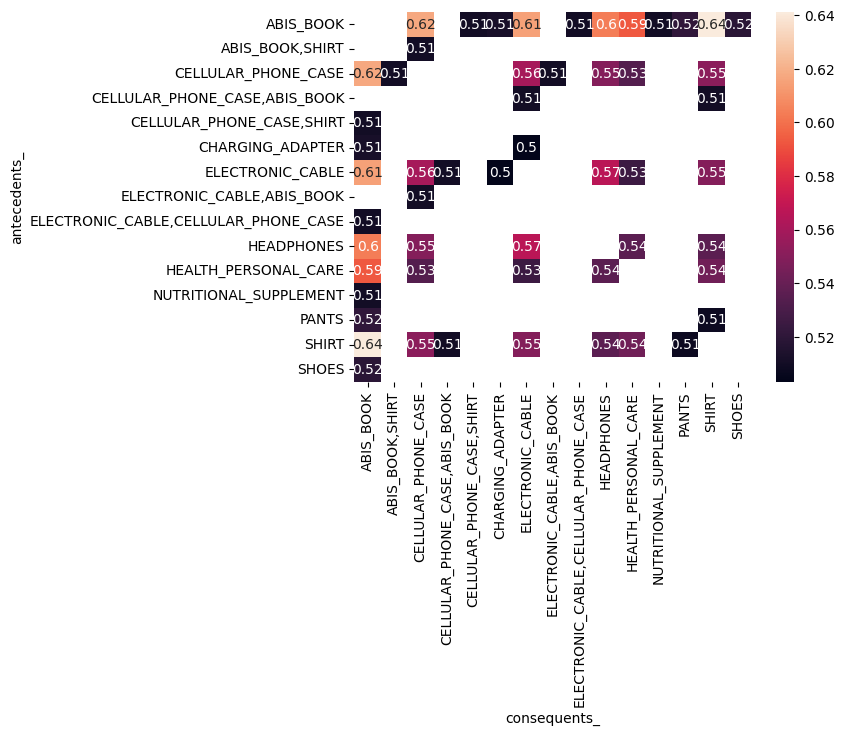

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

rules['lhs items'] = rules['antecedents'].apply(lambda x:len(x) )

# Replace frozen sets with strings
rules['antecedents_'] = rules['antecedents'].apply(lambda a: ','.join(list(a)))
rules['consequents_'] = rules['consequents'].apply(lambda a: ','.join(list(a)))

pivot = rules.pivot(index = 'antecedents_', columns = 'consequents_', values= 'support')

# Generate a heatmap with annotations on and the colorbar off
sns.heatmap(pivot, annot = True)
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.show()

Examining lift, which tells us how much more frequently itemsets appear together than we would expect if they were independent

Lift > 1 indicates a positive association - the purchase of the antecedent increases the probability of the consequent being purchased\
Lift = 1 indicates no association\
Lift < 1 indicates a negative association - the purchase of the antecedent decreases the probability of the consequent being purchased

In [49]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1, num_itemsets=len(transaction_data.index))
rules = rules.sort_values('lift', ascending=False)
rules = rules.head(20)

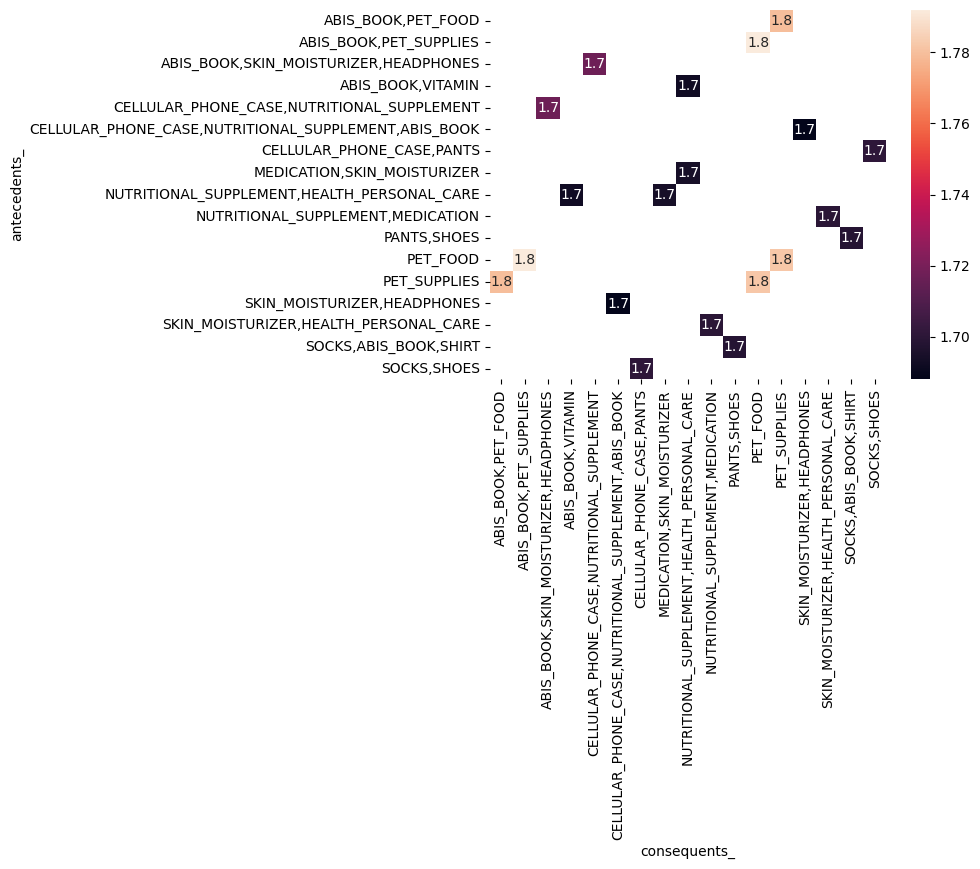

In [50]:
rules['lhs items'] = rules['antecedents'].apply(lambda x:len(x) )

# Replace frozen sets with strings
rules['antecedents_'] = rules['antecedents'].apply(lambda a: ','.join(list(a)))
rules['consequents_'] = rules['consequents'].apply(lambda a: ','.join(list(a)))

# Transform the DataFrame of rules into a matrix using the lift metric
pivot = rules.pivot(index = 'antecedents_', columns = 'consequents_', values= 'lift')

# Generate a heatmap with annotations on and the colorbar off
sns.heatmap(pivot, annot = True)
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.show()